# Multi-Index Fast Gaussian Process

## Setup

In [1]:
import fastgp
from mlqmcpy.problems.elliptic import solve_elliptic_pde

In [2]:
import torch
torch.set_default_dtype(torch.float64)

In [3]:
import matplotlib 
from matplotlib import pyplot,cm
from tueplots import bundles
#pyplot.rcParams.update(bundles.icml2022())
COLORS = ['xkcd:purple', 'xkcd:green', 'xkcd:blue', 'xkcd:red', 'xkcd:turquoise', 'xkcd:pink', 'xkcd:brown', 'xkcd:light blue', 'xkcd:teal', 'xkcd:orange']
pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
WIDTH = 2*(500/72)

## Parameters

In [4]:
budget = 5000
d = 5
num_levels = 2
cost_per_level = 2.**(torch.arange(num_levels)-num_levels+1)
print("cost_per_level = %s"%cost_per_level)
m0 = 8*torch.ones(num_levels,dtype=int)
n0 = 2**m0
print("n0 = %s"%n0)
initial_cost = (n0*cost_per_level).sum()
print("initial_cost = %.1f"%initial_cost)
remaining_budget = budget-initial_cost
print("remaining_budget = %.1f"%remaining_budget)

cost_per_level = tensor([0.5000, 1.0000])
n0 = tensor([256, 256])
initial_cost = 384.0
remaining_budget = 4616.0


## Initial Sampling

In [5]:
fgp = fastgp.FastGPDigitalNetB2(d,seed_for_seq=7,num_tasks=num_levels)
x0s = fgp.get_x_next(n0)
y0s = [torch.tensor([solve_elliptic_pde(level=l,coeffs=x[i].numpy())[0] for i in range(n0[l])]) for l,x in enumerate(x0s)]
fgp.add_y_next(y0s)
data0 = fgp.fit()
print("data")
for l in range(num_levels):
    print("\tx0s[%d].shape = %s"%(l,str(x0s[l].shape)))
    print("\ty0s[%d].shape = %s"%(l,str(y0s[l].shape)))
    print()
pcmean0,pcvar0,_,pcci_low0,pcci_high0 = fgp.post_cubature_ci(task=num_levels-1,confidence=0.99)
print("pcmean0 = %.5f"%pcmean0)
print("pcvar0 = %.2e"%pcvar0)
print("pcci0 = [%.2e , %.2e]"%(pcci_low0,pcci_high0))

     iter of 5.0e+03 | NMLL       | norm term  | logdet term
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 3.63e+03   | 3.77e-02   | 2.69e+03  
            5.00e+00 | 1.54e+03   | 1.21e+00   | 5.96e+02  
            1.00e+01 | -1.22e+03  | 1.04e+03   | -3.20e+03 
            1.50e+01 | -1.83e+03  | 6.37e+02   | -3.41e+03 
            2.00e+01 | -1.98e+03  | 6.17e+02   | -3.54e+03 
            2.50e+01 | -2.00e+03  | 5.37e+02   | -3.48e+03 
            3.00e+01 | -2.02e+03  | 5.32e+02   | -3.49e+03 
            3.50e+01 | -2.03e+03  | 5.14e+02   | -3.48e+03 
            4.00e+01 | -2.03e+03  | 5.26e+02   | -3.50e+03 
            4.50e+01 | -2.04e+03  | 5.21e+02   | -3.50e+03 
            5.00e+01 | -2.04e+03  | 5.38e+02   | -3.52e+03 
            5.50e+01 | -2.04e+03  | 5.31e+02   | -3.51e+03 
            6.00e+01 | -2.04e+03  | 5.10e+02   | -3.49e+03 
            6.50e+01 | -2.04e+03  | 5.14e+02   | -3.50e+03 
            7.00e+01 | -2.04e+03  | 5.

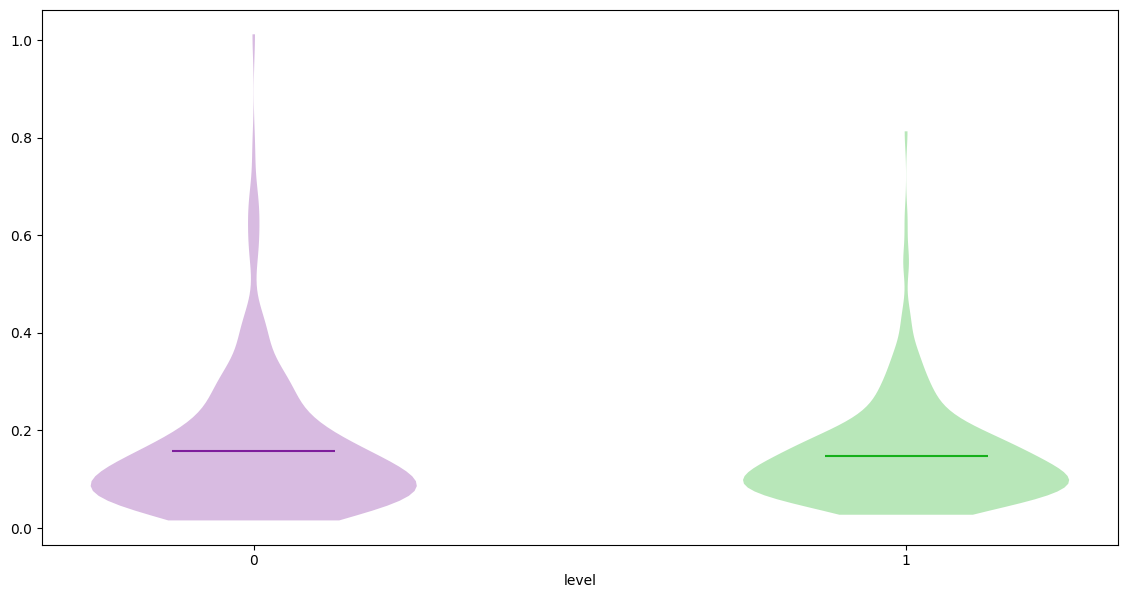

In [6]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH,WIDTH/num_levels))
for l in range(num_levels):
    ax.violinplot(y0s[l],[l],showmeans=True,showextrema=False)
ax.set_xlabel("level")
ax.set_xticks(torch.arange(num_levels));

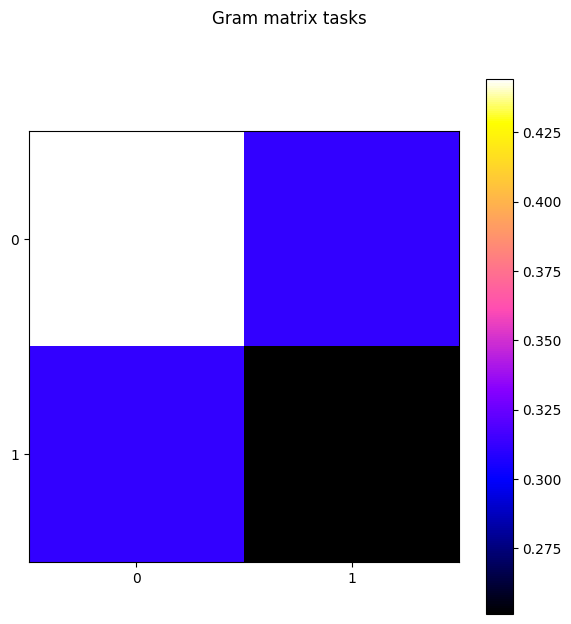

In [7]:
SPACING = .25
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH/2,WIDTH/2))
_imshow = ax.imshow(fgp.gram_matrix_tasks.detach(),cmap=cm.gnuplot2)
fig.colorbar(_imshow)
ax.set_xticks(torch.arange(num_levels))
ax.set_yticks(torch.arange(num_levels))
fig.suptitle("Gram matrix tasks");

## Projections

In [8]:
print("n0 = %s"%n0)
nnew_max = (remaining_budget/cost_per_level).floor().to(int)
print("nnew_max = %s"%nnew_max)
m_max = torch.log2(n0+nnew_max).floor().to(int)
n_max = 2**m_max
print("n_max = %s"%n_max)
assert (n_max>n0).all(), "must have a large enough budget to at least double the same size on the finest level"

n0 = tensor([256, 256])
nnew_max = tensor([9232, 4616])
n_max = tensor([8192, 4096])


In [9]:
m_feasible = [torch.arange(m0[l]+1,m_max[l]+1) for l in range(num_levels)]
for l in range(num_levels):
    print("m_feasible[%d] = %-50s has length %d"%(l,m_feasible[l],len(m_feasible[l])))
num_feasible_combs = torch.tensor([len(m_feasible[l]) for l in range(num_levels)]).prod()
print("num_feasible_combs = %d"%num_feasible_combs)

m_feasible[0] = tensor([ 9, 10, 11, 12, 13])                       has length 5
m_feasible[1] = tensor([ 9, 10, 11, 12])                           has length 4
num_feasible_combs = 20


In [10]:
assert num_levels==2, "the remainder of this notebook has not yet been worked out for num_levels!=2"

In [11]:
mf0_mesh,mf1mesh = torch.meshgrid(m_feasible[0],m_feasible[1],indexing="ij")
mf_comb = torch.vstack([mf0_mesh.flatten(),mf1mesh.flatten()]).T
nf_comb = 2**mf_comb
print("nf_comb.shape = %s"%str(nf_comb.shape))
nf_comb_cost = (nf_comb*cost_per_level).sum(1)
feasible_comb = nf_comb_cost<budget
print("feasible_comb.shape = %s"%str(feasible_comb.shape))

nf_comb.shape = torch.Size([20, 2])
feasible_comb.shape = torch.Size([20])


In [12]:
# should be done more efficiently by only considering the boundary 
pcvars = torch.tensor([fgp.post_cubature_var(task=(num_levels-1),n=nf_comb[i]) for i in range(len(nf_comb))])
print("pcvars.shape = %s"%str(pcvars.shape))
imin = pcvars[feasible_comb].argmin()
pcvars_min = pcvars[feasible_comb][imin]
print("pcvars_min = %.2e"%pcvars_min)
n = nf_comb[feasible_comb][imin]
print("n = %s"%n)

pcvars.shape = torch.Size([20])
pcvars_min = 1.29e-06
n = tensor([1024, 4096])


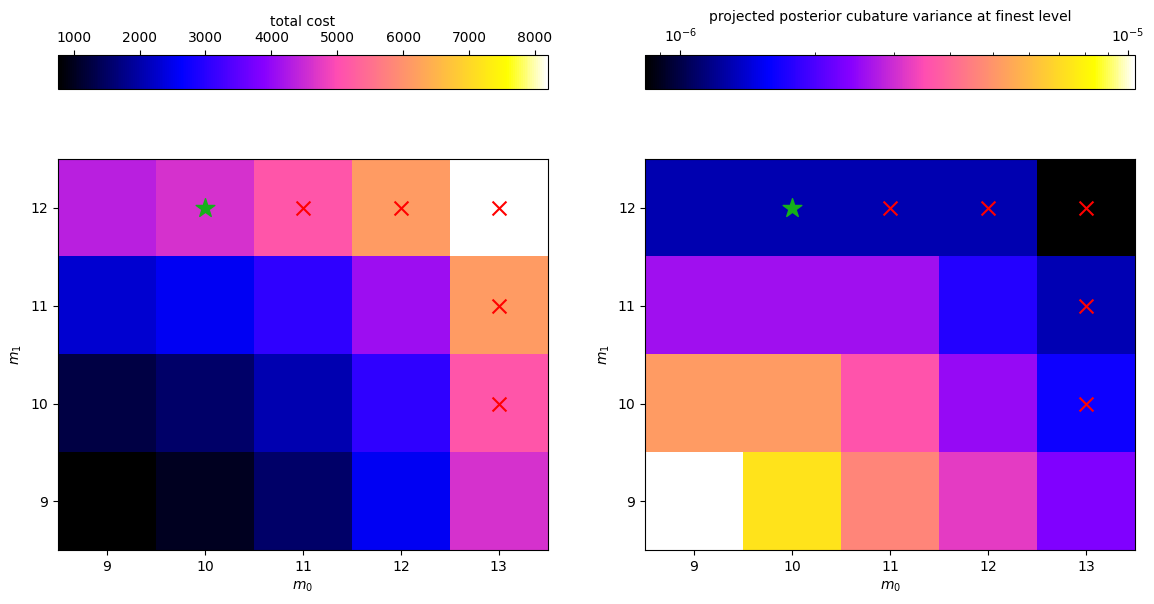

In [13]:
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(WIDTH,WIDTH/2))
_imshow = ax[0].imshow(nf_comb_cost.reshape(mf0_mesh.shape).T,cmap=cm.gnuplot2)
_axp = ax[0].get_position()
_cax = fig.add_axes([_axp.x0,_axp.y1+0.1,_axp.x1-_axp.x0,0.05])
fig.colorbar(_imshow,_cax,location="top",label="total cost")
_imshow = ax[1].imshow(pcvars.reshape(mf0_mesh.shape).T,cmap=cm.gnuplot2,norm="log")
_axp = ax[1].get_position()
_cax = fig.add_axes([_axp.x0,_axp.y1+0.1,_axp.x1-_axp.x0,0.05])
fig.colorbar(_imshow,_cax,location="top",label="projected posterior cubature variance at finest level")
for i in range(2):
    ax[i].invert_yaxis()
    ax[i].scatter(mf_comb[feasible_comb][imin,0]-(m0[0]+1),mf_comb[feasible_comb][imin,1]-(m0[1]+1),color=COLORS[1],marker="*",s=200)
    ax[i].scatter(mf_comb[~feasible_comb,0]-(m0[0]+1),mf_comb[~feasible_comb,1]-(m0[1]+1),marker="x",s=100,color="red")
    ax[i].set_xlabel(r"$m_0$")
    ax[i].set_xticks(torch.arange(len(m_feasible[0])))
    ax[i].set_xticklabels([r"$%d$"%_m for _m in m_feasible[0]])
    ax[i].set_ylabel(r"$m_1$")
    ax[i].set_yticks(torch.arange(len(m_feasible[1])))
    ax[i].set_yticklabels([r"$%d$"%_m for _m in m_feasible[1]])

## Final Sampling

In [14]:
# running this cell multiple times will give errors as it tries to keep adding more and more samples 
xs = fgp.get_x_next(n)
ys = [torch.tensor([solve_elliptic_pde(level=l,coeffs=x[i].numpy())[0] for i in range(n[l]-n0[l])]) for l,x in enumerate(xs)]
fgp.add_y_next(ys)
data = fgp.fit()
print("data")
for l in range(num_levels):
    print("\txs[%d].shape = %s"%(l,str(xs[l].shape)))
    print("\tys[%d].shape = %s"%(l,str(ys[l].shape)))
    print()
print("pcmean = %.5f"%pcmean0)
print("pcvar = %.2e"%pcvar0)
print("pcci = [%.2e , %.2e]"%(pcci_low0,pcci_high0))
print()
print("pcvars_min = %.2e"%pcvars_min)
print()
pcmean,pcvar,_,pcci_low,pcci_high = fgp.post_cubature_ci(task=num_levels-1,confidence=0.99)
print("pcmean = %.5f"%pcmean)
print("pcvar = %.2e"%pcvar)
print("pcci = [%.2e , %.2e]"%(pcci_low,pcci_high))

     iter of 5.0e+03 | NMLL       | norm term  | logdet term
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | -2.89e+04  | 5.73e+03   | -4.41e+04 
            5.00e+00 | -2.92e+04  | 5.59e+03   | -4.42e+04 
            1.00e+01 | -2.94e+04  | 5.70e+03   | -4.45e+04 
            1.50e+01 | -2.94e+04  | 5.19e+03   | -4.40e+04 
            2.00e+01 | -2.94e+04  | 5.00e+03   | -4.38e+04 
            2.50e+01 | -2.94e+04  | 5.11e+03   | -4.40e+04 
            3.00e+01 | -2.94e+04  | 5.02e+03   | -4.39e+04 
            3.50e+01 | -2.95e+04  | 5.07e+03   | -4.39e+04 
            4.00e+01 | -2.95e+04  | 5.08e+03   | -4.39e+04 
            4.50e+01 | -2.95e+04  | 5.11e+03   | -4.40e+04 
            5.00e+01 | -2.95e+04  | 5.04e+03   | -4.39e+04 
            5.50e+01 | -2.95e+04  | 5.13e+03   | -4.40e+04 
            6.00e+01 | -2.95e+04  | 5.09e+03   | -4.40e+04 
            6.50e+01 | -2.95e+04  | 5.10e+03   | -4.40e+04 
            7.00e+01 | -2.95e+04  | 5.